In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

Downloading data of Apple(from "2021-01-01" to "2024-01-01") from yfinance

In [ ]:
ticker="AAPL"
df=yf.download(ticker,start="2021-01-01",end="2024-01-01")
print(df.shape)
df.head()

/tmp/ipykernel_1995/3695097770.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download(ticker,start="2021-01-01",end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

(753, 5)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-01-04,125.740860,129.821775,123.165994,129.734330,143301900
2021-01-05,127.295464,128.004777,124.788613,125.235577,97664900
2021-01-06,123.010513,127.334347,122.796750,124.098761,155088000
2021-01-07,127.208000,127.897876,124.234763,124.720587,109578200
2021-01-08,128.306015,128.869572,126.537610,128.675231,105158200


# Part-1: Return Profile and Benchmark
Computing daily log returns and benchmark statistics for buy & hold AAPL.

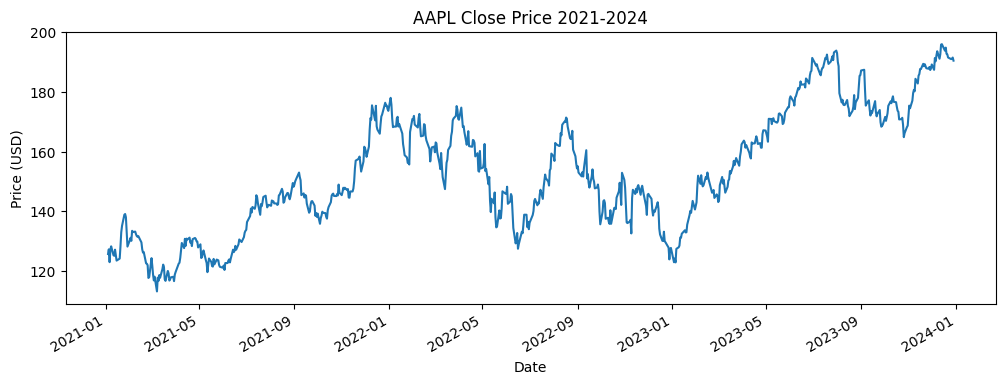

In [ ]:
close=df['Close']['AAPL']
close.plot(title='AAPL Close Price 2021-2024',figsize=(12,4))
plt.ylabel('Price (USD)')
plt.show()

calculating the log returns and plotting its graph

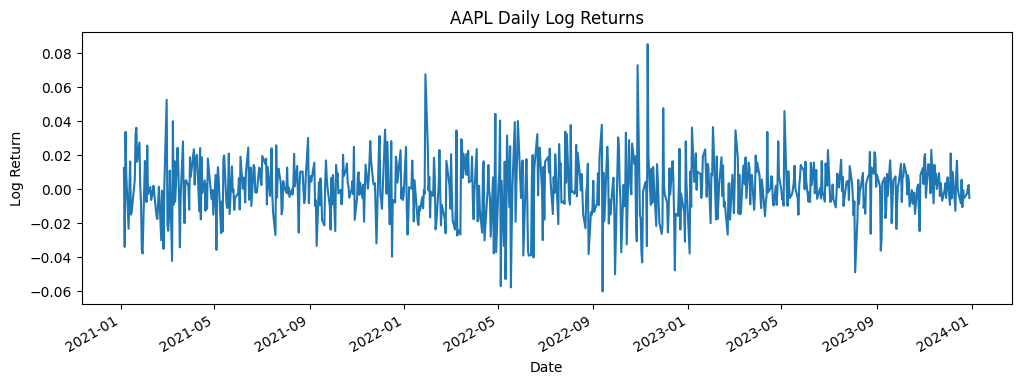

In [ ]:
log_returns=np.log(close/close.shift(1)).dropna()
log_returns.plot(title='AAPL Daily Log Returns', figsize=(12,4))
plt.ylabel('Log Return')
plt.show()

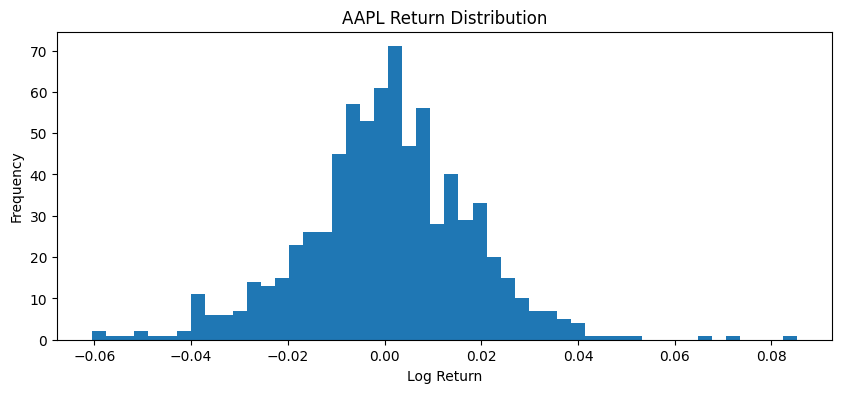

In [ ]:
plt.figure(figZsize=(10,4))
log_returns.plot.hist(bins=50, title='AAPL Return Distribution')
plt.xlabel('Log Return')
plt.show()

Distribution is approximately normal(bell curve) but exhibits fat tails(tailes extend to -6% to +8%). A perfect normal curve doesn't have that extreme so often.

In [ ]:
mean_daily=log_returns.mean()
ann_return=mean_daily*252
ann_volatility=log_returns.std()* np.sqrt(252)
sharpe=ann_return/ann_volatility

print(f"Mean Daily Return: {mean_daily:.4f}")
print(f"Annualised Return: {ann_return:.4f}")
print(f"Annualised Volatility: {ann_volatility:.4f}")
print(f"Sharpe Ratio: {sharpe:.4f}")

Mean Daily Return: 0.0006
Annualised Return: 0.1390
Annualised Volatility: 0.2777
Sharpe Ratio: 0.5005


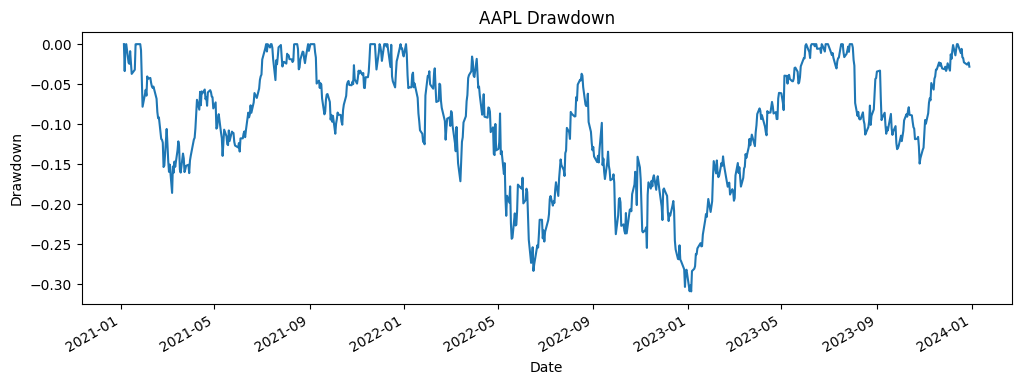

Max Drawdown: -0.3091


In [ ]:
equity_curve=log_returns.cumsum().apply(np.exp) #adds up return day by day
rolling_max=equity_curve.cummax() #Tracks the highest value reached so far at each point in time.
drawdown=(equity_curve-rolling_max)/rolling_max
max_drawdown=drawdown.min() #how far are you below peak right now??


drawdown.plot(title='AAPL Drawdown', figsize=(12,4))
plt.ylabel('Drawdown')
plt.show()

print(f"Max Drawdown: {max_drawdown:.4f}")

In [ ]:
best_day=log_returns.idxmax()
worst_day=log_returns.idxmin()

print(f"Best Day: {best_day.date()} → {log_returns[best_day]:.4f}")
print(f"Worst Day: {worst_day.date()} → {log_returns[worst_day]:.4f}")


Best Day: 2022-11-10 → 0.0852
Worst Day: 2022-09-13 → -0.0605


# Summary of Part-1
Mean daily return → 0.006

annualised return → 0.1390

Annualised volatility (daily std × √252) → 0.277

Annualised Sharpe ratio → 0.5005

Maximum drawdown over the full sample period → -0.3091

Best Day: 2022-11-10 → 0.0852

Worst Day: 2022-09-13 → -0.0605

***Distribution is almost normall(bell curve) but it contains fat tails -- extreme moves beyond ±4% occur more than a normal distribution predicts.***


# Hypothesis
When the 5-day Moving Average crosses above the 20-day Moving Average, I predict that the market will grow. Short term prices increasing implies recent momentum is building. Traders already gaining profit would likely not sell their shares, and other people seeing the trend will buy these stocks, pushing prices further up.

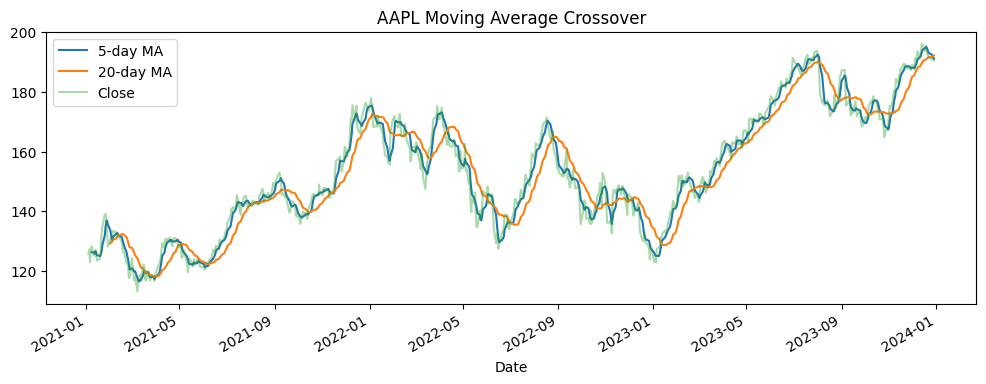

In [ ]:
ma5=close.rolling(5).mean() # mean of last 5 days
ma20=close.rolling(20).mean()

signal=(ma5>ma20).astype(int)

ma5.plot(label='5-day MA', figsize=(12,4))
ma20.plot(label='20-day MA')
close.plot(label='Close', alpha=0.4)
plt.legend()
plt.title('AAPL Moving Average Crossover')
plt.show()

In [ ]:
strategy_returns= log_returns * signal.shift(1) # shifting by 1 because we can't use todays sigla to trade since it comes after market closes

ann_return_strat= strategy_returns.mean() *252
ann_vol_strat=strategy_returns.std()*np.sqrt(252)
sharpe_strat=ann_return_strat/ann_vol_strat

print(f"Strategy Annualised Return: {ann_return_strat:.4f}")
print(f"Strategy Annualised Volatility: {ann_vol_strat:.4f}")
print(f"Strategy Sharpe Ratio: {sharpe_strat:.4f}")

Strategy Annualised Return: 0.1633
Strategy Annualised Volatility: 0.1811
Strategy Sharpe Ratio: 0.9020


In [ ]:
strat_equity=strategy_returns.cumsum().apply(np.exp)
strat_rolling_max=strat_equity.cummax()
strat_drawdown=(strat_equity-strat_rolling_max)/strat_rolling_max
strat_max_drawdown=strat_drawdown.min()

print(f"Strategy Max Drawdown: {strat_max_drawdown:.4f}")
print(f"Benchmark Max Drawdown: {max_drawdown:.4f}")

Strategy Max Drawdown: -0.2027
Benchmark Max Drawdown: -0.3091


## Part 2 — Signal Analysis: Moving Average Crossover

Signal: When 5-day MA crosses above 20-day MA → buy (signal=1), else stay out (signal=0)

In [ ]:
# Average return in each signal state
next_5_return=log_returns.rolling(5).sum().shift(-5)
signal_on=next_5_return[signal==1].mean()
signal_off=next_5_return[signal==0].mean()

print(f"Avg 5-day return when signal ON: {signal_on:.4f}")
print(f"Avg 5-day return when signal OFF: {signal_off:.4f}")

Avg 5-day return when signal ON: 0.0027
Avg 5-day return when signal OFF: 0.0029


Signal ON → avg 5-day return: 0.27%
Signal OFF → avg 5-day return: 0.29%

The difference is negligible — the signal does not strongly predict
short-term price direction. However, by staying out during high-volatility
periods, the strategy achieves better Sharpe and lower drawdown than buy & hold.

# Part 3: Honest Assessment

Q.1 What is the single biggest reason this result might not hold in live trading?

One of the reasons I think this result migh not hold in live trading could be that many traders uses similar signals. this signal check on the historical data which might not be much relevant for live trading.

Q.2 How many genuinely independent observations does your sample contain?

There are approximately 37(753/20) independent signal observation. This means that the Sharpe ratio of 0.90 has hig uncertainty.

Q.3 Looking at your Sharpe and drawdown numbers together: is your signal a genuine improvement over buy-and-hold, a tradeoff, or worse on both?

The signal represents a genuine improvement over buy & hold on all four metrics — higher annualised return (16.3% vs 13.9%), lower volatility (18.1% vs 27.8%), higher Sharpe (0.90 vs 0.50), and smaller max drawdown (-20.3% vs -30.9%).However the signal does not predict direction well — 5-day forward returns are nearly identical whether signal is ON or OFF (0.27% vs 0.29%). This strategy wins by avoiding volatile crash periods rather than timing direction correctly. Some gains are missed when signal is off, but avoiding large drawdowns more than compensates.